In [ ]:
# Mulitple Linear Regression
# take multiple input features 
# house dataset -> all features as our input features
# Area, Bedrooms, Bathrooms - numerical features - numerical values
# Material,	Locality - categorical features
# ML model - takes only numerical features
# Another step is needed - handling categorical features - convert them into numerical values


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load dataset
df = pd.read_csv("house.csv")
df.head()

,Area,Bedrooms,Bathrooms,Material,Locality,Price
0,1790,2,2,Concrete,Riverside,114300
1,2030,4,2,Concrete,Riverside,114200
2,1740,3,2,Concrete,Riverside,114800
3,1980,3,2,Concrete,Riverside,94700
4,2130,3,3,Concrete,Riverside,119800


In [ ]:
# Handle Categorical Columns/Features
# in pandas we have get_dummies - convert categorical columns to numeric using one hot encoding

In [7]:
df_encoded = pd.get_dummies(df, columns=['Material','Locality'], drop_first=True, dtype=int)
df_encoded.head(20)

,Area,Bedrooms,Bathrooms,Price,Material_Masonry,Locality_Riverside,Locality_Summit View
0,1790,2,2,114300,0,1,0
1,2030,4,2,114200,0,1,0
2,1740,3,2,114800,0,1,0
3,1980,3,2,94700,0,1,0
4,2130,3,3,119800,0,1,0
5,1780,3,2,114600,0,0,0
6,1830,3,3,151600,1,0,1
7,2160,4,2,150700,0,0,1
8,2110,4,2,119200,0,1,0
9,1730,3,3,104000,0,1,0


In [9]:
# Select features and target

# X -> take all features from df_encoded except Price
# y -> take only Price

X = df_encoded.drop('Price', axis=1)  # drop only the Price column
y = df_encoded['Price']

In [11]:
# Split the dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction on testing set
y_test_pred = model.predict(X_test)

# Evaluate the model
print("Testing Data : RMSE", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Testing Data : r2_score", r2_score(y_test, y_test_pred))

Testing Data : RMSE 11914.45529347113
Testing Data : r2_score 0.7591542040198597


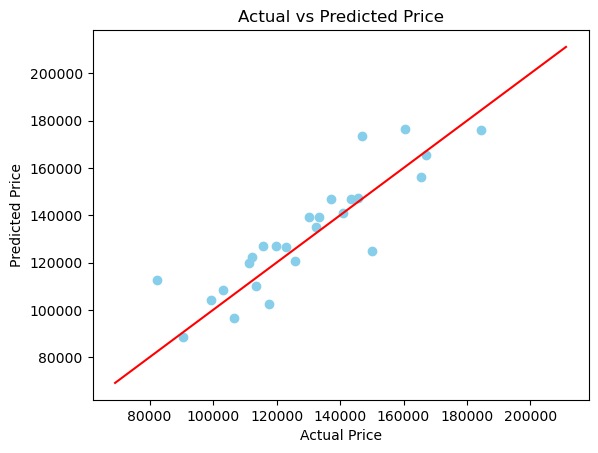

In [15]:
# Visualise Actual vs Predicted on Testing data
plt.scatter(y_test, y_test_pred, color='skyblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')
plt.xlabel('Actual Price')  # y_test
plt.ylabel('Predicted Price') # y_test_pred
plt.title("Actual vs Predicted Price")
plt.show()

In [19]:
# y = m1x1 + m2x2 + m3x3+......+ c

# Interpret the coefficients

coeffs = pd.DataFrame({
        'Feature' : X.columns,
        'Coefficient' : model.coef_
})
print(coeffs)
print()
# print intercept
print("Model Intercept : ", model.intercept_)

                Feature   Coefficient
0                  Area     39.123219
1              Bedrooms   2077.048558
2             Bathrooms   5932.658403
3      Material_Masonry  17754.525853
4    Locality_Riverside   6699.355635
5  Locality_Summit View  35661.026817

Model Intercept :  12905.286687652915


In [ ]:
# Importance 
# Model coeffs -> value - weight that is assigned to each feature
#              -> telling how much each feature contributes to the prediction
#              -> positive -> if these values increase, price will also increase
#              -> negative -> if value increasee, price decreses
#              -> magnitude -> higher it is, more stronger the features is affecting the output
# Model intercept -> predicted value of y when all i/p features are 0

In [23]:
new_values = np.array([[1235,3,4,0,0,1],
                       [5687,3,2,1,0,1]])
predicted_prices = model.predict(new_values)
print(predicted_prices)

[126845.26766593 306911.04556887]


C:\Users\Vandana\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
